LAB 4

Maxwell

Alex



https://www.kaggle.com/datasets/mansoordaku/ckdisease

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
unique_names = df['classification'].unique()
print(unique_names)
#checks for unique values in the classification column to understand the dataset

['ckd' 'ckd\t' 'notckd']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label = le.fit_transform(df['classification'])
df.drop('classification',axis=1, inplace=True)
df['classification'] = label
df
#transforms classification data into numerical data that can be visualized with our model

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,0
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,0
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,0
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,0
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,2
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,2
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,2
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,2


In [ ]:
df = df.drop(columns=['pc','pcc','ba','htn','dm','cad','appet','pe','ane','rbc','id'])
#drops categorical columns to focus on compatible data types as we normalize


In [ ]:
df

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,classification
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,0
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,0
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,0
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,2
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,2
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,2
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,2


In [ ]:
from sklearn import preprocessing

In [ ]:
df = df.dropna()
#drops all NaN values

In [ ]:
label = df['classification']
df_numerical = df.drop(columns=['classification'])

df_scaled_array = preprocessing.scale(df_numerical)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_numerical.columns)
df_scaled['classification'] = label.values
df = df_scaled

#standardizes the data, leaving out the target column of classification to preserve it

In [ ]:
df.isnull().sum()
#check for null values

,0
age,0
bp,0
sg,0
al,0
su,0
bgr,0
bu,0
sc,0
sod,0
pot,0


In [ ]:
df

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,classification
0,-0.247206,-0.428141,-2.493056,2.342066,-0.370974,-0.279313,0.060094,0.527328,-4.021049,-0.672186,-0.758744,-0.972603,-0.648147,-0.889670,0
1,0.521879,1.310111,-0.717300,1.604951,-0.370974,-0.850436,-0.618851,-0.391974,0.477522,-0.444763,-0.404908,-0.187337,-0.271439,-0.389107,0
2,0.073246,1.310111,0.170577,0.867835,-0.370974,-0.903564,1.177068,1.684966,-3.585703,-0.282318,-1.360267,-1.309146,1.201147,-1.089895,0
3,0.714150,-0.428141,-1.605178,1.604951,-0.370974,3.213836,0.147700,0.152798,-1.118745,-0.119873,-0.900279,-0.972603,-1.401563,-0.989782,0
4,1.034602,-0.428141,-0.717300,1.604951,0.660639,0.929343,0.410517,-0.051492,-0.102939,0.399951,-1.289499,-1.421326,1.235393,-1.390232,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,0.201427,0.440985,0.170577,-0.606395,-0.370974,0.026171,-0.093216,-0.596263,1.638443,0.107550,0.833521,0.710111,-0.648147,0.111455,2
199,-0.631748,-0.428141,1.058455,-0.606395,-0.370974,-0.837154,-0.487442,-0.357925,0.332407,-0.347296,1.116590,1.495377,-0.271439,1.412918,2
200,-2.554460,0.440985,0.170577,-0.606395,-0.370974,-0.505106,-0.596949,-0.562215,-0.248054,-0.054895,0.868904,0.934472,-0.682393,0.612018,2
201,-2.234008,-1.297267,1.058455,-0.606395,-0.370974,-0.319159,-0.071315,-0.426022,-0.538284,0.107550,0.302766,1.158834,-0.476916,1.112581,2


In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df)
#reduces the components of the dataset into 2 principal components for visualization

In [ ]:
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
#wraps pca in a dataframe

In [ ]:
print("\nExplained varience per component:")
print("   PC1: {:.1%}   |  PC2 {:.1%}".format(*pca.explained_variance_ratio_))
#shows the varience each PCA component explains, showing that PC1 accounts for the most


Explained varience per component:
   PC1: 46.5%   |  PC2 10.6%


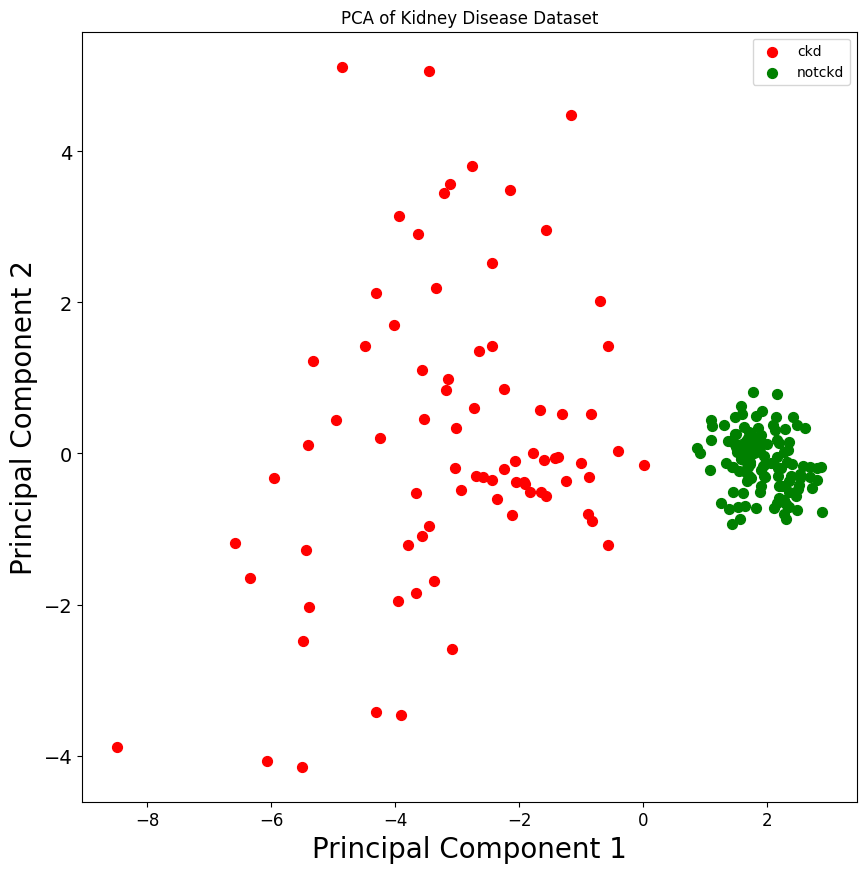

In [ ]:
#scatter plot represents different samples of patients screened for kidney disease

plt.figure(figsize=(10,10))
plt.xlabel('Principal Component 1', fontsize=20)
plt.ylabel('Principal Component 2', fontsize=20)
plt.title('PCA of Kidney Disease Dataset')
plt.xticks(fontsize=12); plt.yticks(fontsize=14)
#diagnoses of chronic kidney disease or not chronic kidney disease represented with red and green respectively
colors = {0: ('r', 'ckd'), 2: ('g', 'notckd')}
for label, (color,name) in colors.items():
    mask = df['classification'] == label
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=color, s=50, label=name)
plt.legend()

#We used PCA to simplify a chronic kidney disease dataset which takes medical measurements and reduces them into two main components so patterns are more visible. There is a seperation between patients with kidney disease and those without. There is a strong difference between the two groups.